In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from datasets import load_dataset
import pandas as pd
from PIL import Image

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

In [8]:

class Agent(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = torchvision.models.resnet18()

        self.state = nn.Sequential(
            nn.Linear(1000, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
        )

        self.keyboard = nn.Linear(512, 7)
        self.mouse_buttons = nn.Linear(512, 2)
        self.mouse_pos = nn.Linear(512, 2)

    def forward(self, image):
        x = self.backbone(image)
        x = self.state(x)
        keys = self.keyboard(x)
        mouse_pos = self.mouse_pos(x)
        mouse_buttons = self.mouse_buttons(x)

        return mouse_pos, mouse_buttons, keys


In [9]:

model = Agent()
model = model.to(device)

x = torch.randn(1, 3, 224, 224).to(device)

mouse_pos, mouse_buttons, keys = model(x)

print(keys.shape)
print(mouse_pos.shape)
print(mouse_buttons.shape)


torch.Size([1, 7])
torch.Size([1, 2])
torch.Size([1, 2])


In [10]:

# Загружаем датасет
ds = load_dataset(
    "Erik606/roblox-rivals-gameplay-dataset",
    split="train"
)


In [11]:

# Dataset
from io import BytesIO

from torchvision import transforms


class RobloxDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(BytesIO(row["image"])).convert("RGB")

        if self.transform:
            image = self.transform(image)

        mouse_pos = torch.tensor(
            [row["mouse_x"], row["mouse_y"]],
            dtype=torch.float32,
        )

        mouse_buttons = torch.tensor(
            [row["mouse_left"], row["mouse_right"]],
            dtype=torch.float32,
        )

        keys = torch.tensor(
            [
                row["key_w"],
                row["key_a"],
                row["key_s"],
                row["key_d"],
                row["key_space"],
                row["key_shift"],
                row["key_ctrl"],
            ],
            dtype=torch.float32,
        )

        return image, mouse_pos, mouse_buttons, keys


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


dataset = RobloxDataset(ds.to_pandas(), transform)

from torch.utils.data import DataLoader, random_split

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

3060
382
384


In [12]:

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-2,
)

key_loss = nn.BCEWithLogitsLoss()
mouse_button_loss = nn.BCEWithLogitsLoss()
mouse_pos_loss = nn.SmoothL1Loss()


In [13]:
from tqdm.auto import tqdm


def train_one_epoch(
    model,
    loader,
    optimizer,
    key_loss_fn,
    mouse_button_loss_fn,
    mouse_pos_loss_fn,
    device,
    mouse_pos_weight=1.0,
):
    model.train()

    total_loss = 0.0
    total_key_loss = 0.0
    total_button_loss = 0.0
    total_mouse_loss = 0.0

    progress = tqdm(loader, desc="Train", leave=False)

    for images, mouse_pos, mouse_buttons, keys in progress:
        images = images.to(device)
        mouse_pos = mouse_pos.to(device)
        mouse_buttons = mouse_buttons.to(device)
        keys = keys.to(device)

        optimizer.zero_grad()

        pred_mouse_pos, pred_mouse_buttons, pred_keys = model(images)

        loss_keys = key_loss_fn(pred_keys, keys)
        loss_buttons = mouse_button_loss_fn(
            pred_mouse_buttons,
            mouse_buttons
        )
        loss_mouse = mouse_pos_loss_fn(
            pred_mouse_pos,
            mouse_pos
        )

        loss = (
            loss_keys
            + loss_buttons
            + mouse_pos_weight * loss_mouse
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_key_loss += loss_keys.item()
        total_button_loss += loss_buttons.item()
        total_mouse_loss += loss_mouse.item()

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    n = len(loader)

    return {
        "loss": total_loss / n,
        "key_loss": total_key_loss / n,
        "button_loss": total_button_loss / n,
        "mouse_loss": total_mouse_loss / n,
    }


In [14]:

@torch.no_grad()
def validate(
    model,
    loader,
    key_loss_fn,
    mouse_button_loss_fn,
    mouse_pos_loss_fn,
    device,
    mouse_pos_weight=1.0,
):
    model.eval()

    total_loss = 0.0
    total_key_loss = 0.0
    total_button_loss = 0.0
    total_mouse_loss = 0.0

    progress = tqdm(loader, desc="Val", leave=False)

    for images, mouse_pos, mouse_buttons, keys in progress:
        images = images.to(device)
        mouse_pos = mouse_pos.to(device)
        mouse_buttons = mouse_buttons.to(device)
        keys = keys.to(device)

        pred_mouse_pos, pred_mouse_buttons, pred_keys = model(images)

        loss_keys = key_loss_fn(pred_keys, keys)
        loss_buttons = mouse_button_loss_fn(
            pred_mouse_buttons,
            mouse_buttons
        )
        loss_mouse = mouse_pos_loss_fn(
            pred_mouse_pos,
            mouse_pos
        )

        loss = (
            loss_keys
            + loss_buttons
            + mouse_pos_weight * loss_mouse
        )

        total_loss += loss.item()
        total_key_loss += loss_keys.item()
        total_button_loss += loss_buttons.item()
        total_mouse_loss += loss_mouse.item()

    n = len(loader)

    return {
        "loss": total_loss / n,
        "key_loss": total_key_loss / n,
        "button_loss": total_button_loss / n,
        "mouse_loss": total_mouse_loss / n,
    }



In [ ]:

from copy import deepcopy

EPOCHS = 20

history = {
    "train_loss": [],
    "val_loss": [],
    "train_key_loss": [],
    "val_key_loss": [],
    "train_button_loss": [],
    "val_button_loss": [],
    "train_mouse_loss": [],
    "val_mouse_loss": [],
}

best_val_loss = float("inf")
best_state = None


for epoch in range(1, EPOCHS + 1):

    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_metrics = train_one_epoch(
        model,
        train_loader,
        optimizer,
        key_loss,
        mouse_button_loss,
        mouse_pos_loss,
        device,
    )

    val_metrics = validate(
        model,
        val_loader,
        key_loss,
        mouse_button_loss,
        mouse_pos_loss,
        device,
    )

    # History
    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])

    history["train_key_loss"].append(train_metrics["key_loss"])
    history["val_key_loss"].append(val_metrics["key_loss"])

    history["train_button_loss"].append(train_metrics["button_loss"])
    history["val_button_loss"].append(val_metrics["button_loss"])

    history["train_mouse_loss"].append(train_metrics["mouse_loss"])
    history["val_mouse_loss"].append(val_metrics["mouse_loss"])

    print(
        f"train: {train_metrics['loss']:.4f} | "
        f"val: {val_metrics['loss']:.4f}"
    )

    print(
        f"  keys:    {train_metrics['key_loss']:.4f} → "
        f"{val_metrics['key_loss']:.4f}"
    )

    print(
        f"  buttons: {train_metrics['button_loss']:.4f} → "
        f"{val_metrics['button_loss']:.4f}"
    )

    print(
        f"  mouse:   {train_metrics['mouse_loss']:.4f} → "
        f"{val_metrics['mouse_loss']:.4f}"
    )

    # Save best model
    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_state = deepcopy(model.state_dict())

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": best_val_loss,
            },
            "model/best_model.pt",
        )

        print("  ✓ best model saved")





Epoch 1/20


train: 555.9453 | val: 70.5383
  keys:    0.4639 → 0.3685
  buttons: 0.4106 → 0.2558
  mouse:   555.0707 → 69.9139
  ✓ best model saved

Epoch 2/20


train: 52.0229 | val: 50.9472
  keys:    0.3912 → 0.4093
  buttons: 0.2734 → 0.2534
  mouse:   51.3583 → 50.2844
  ✓ best model saved

Epoch 3/20


train: 49.0762 | val: 79.5759
  keys:    0.4024 → 0.3962
  buttons: 0.2672 → 0.2612
  mouse:   48.4066 → 78.9184

Epoch 4/20


train: 50.0406 | val: 63.8016
  keys:    0.3834 → 0.3606
  buttons: 0.2665 → 0.3126
  mouse:   49.3908 → 63.1284

Epoch 5/20


...

train: 40.1250 | val: 50.8786
  keys:    0.3837 → 0.3567
  buttons: 0.2657 → 0.2391
  mouse:   39.4756 → 50.2828

Epoch 17/20


train: 40.6348 | val: 59.8279
  keys:    0.3892 → 0.4234
  buttons: 0.2890 → 0.2941
  mouse:   39.9566 → 59.1104

Epoch 18/20


train: 40.9825 | val: 47.7648
  keys:    0.3881 → 0.4043
  buttons: 0.2587 → 0.2485
  mouse:   40.3357 → 47.1121
  ✓ best model saved

Epoch 19/20


train: 41.4394 | val: 62.4430
  keys:    0.3811 → 0.4097
  buttons: 0.2808 → 0.3505
  mouse:   40.7775 → 61.6829

Epoch 20/20


train: 42.9335 | val: 63.6675
  keys:    0.3944 → 0.4114
  buttons: 0.2510 → 0.2243
  mouse:   42.2880 → 63.0318


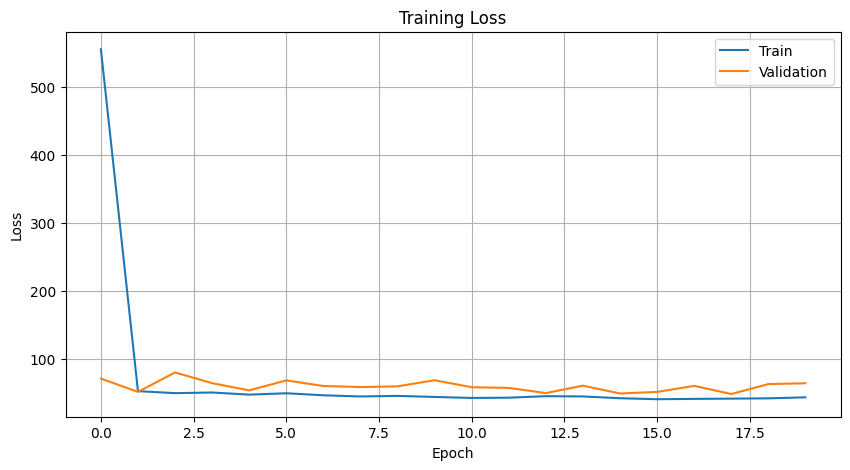

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.legend()
plt.grid()
plt.show()

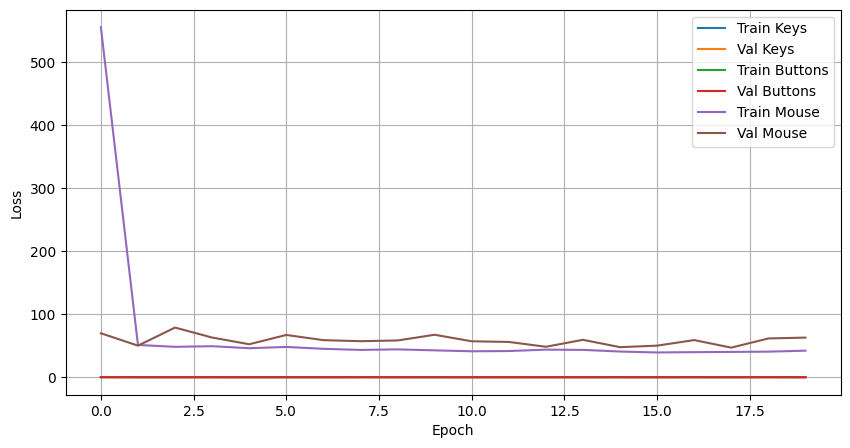

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(history["train_key_loss"], label="Train Keys")
plt.plot(history["val_key_loss"], label="Val Keys")

plt.plot(history["train_button_loss"], label="Train Buttons")
plt.plot(history["val_button_loss"], label="Val Buttons")

plt.plot(history["train_mouse_loss"], label="Train Mouse")
plt.plot(history["val_mouse_loss"], label="Val Mouse")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()